In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# biblioteca do scikit-learn para divisão dos dados
from sklearn.model_selection import train_test_split

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)



In [2]:
# definindo caminhos
pasta_dados = '../dados/dados_processados/'
pasta_modelos = '../modelos/'

print("Carregando as 3 versões dos atributos\n")

X_original = pd.read_csv(os.path.join(pasta_dados, 'atributos_amostrados.csv'))
X_pca = pd.read_csv(os.path.join(pasta_dados, 'atributos_pca.csv'))
X_lda = pd.read_csv(os.path.join(pasta_dados, 'atributos_lda.csv'))

# carregando os rótulos 
y = pd.read_csv(os.path.join(pasta_dados, 'rotulos_amostrados.csv')).iloc[:, 0]

# carregando o codificador
codificador = joblib.load(os.path.join(pasta_modelos, 'codificador_rotulos_amostrado.pkl'))

print("Dados carregados\n")
print(f" Atributos - original:  {X_original.shape}")
print(f" Atributos - pca:       {X_pca.shape}")
print(f" Atributos - lda:       {X_lda.shape}")

print(f"\n Classes: {list(codificador.classes_)}")


Carregando as 3 versões dos atributos

Dados carregados

 Atributos - original:  (10000, 78)
 Atributos - pca:       (10000, 15)
 Atributos - lda:       (10000, 3)

 Classes: ['BENIGN', 'DDoS', 'DoS Hulk', 'PortScan']


In [3]:
# definindo as configurações da divisão treino/teste
PROPORCAO_TESTE = 0.30   # 30% para teste, 70% para treino
SEMENTE = 1              # seed igual as etapas anteriores

print(" Configurações da divisão:")
print("=" * 50)
print(f" Proporção de treino:  {(1-PROPORCAO_TESTE)*100:.0f}%")
print(f" Proporção de teste:   {PROPORCAO_TESTE*100:.0f}%")
print(f" Estratificação:       Ativada (mantém a proporção das classes)")
print(f" Semente aleatória:    {SEMENTE}")
print("=" * 50)

# calculando quantos registros cada conjunto terá
n_total = len(y)
n_teste_esperado = int(n_total * PROPORCAO_TESTE)
n_treino_esperado = n_total - n_teste_esperado

print(f"\n Distribuição esperada:")
print(f"   Total:  {n_total:,} registros")
print(f"   Treino: {n_treino_esperado:,} registros (~{(1-PROPORCAO_TESTE)*100:.0f}%)")
print(f"   Teste:  {n_teste_esperado:,} registros (~{PROPORCAO_TESTE*100:.0f}%)")


 Configurações da divisão:
 Proporção de treino:  70%
 Proporção de teste:   30%
 Estratificação:       Ativada (mantém a proporção das classes)
 Semente aleatória:    1

 Distribuição esperada:
   Total:  10,000 registros
   Treino: 7,000 registros (~70%)
   Teste:  3,000 registros (~30%)


In [4]:
# dividindo cada uma das 3 versões dos dados
# usamos a mesma semente para garantir que as mesmas linhas vão para treino/teste em todas

print("Realizando divisão treino/teste\n")

# versão 1 com dados originais
X_train_orig, X_test_orig, y_train, y_test = train_test_split(
    X_original, y,
    test_size=PROPORCAO_TESTE,
    random_state=SEMENTE,
    stratify=y       # estratificação
)

# versão 2 com dados com PCA
X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y,
    test_size=PROPORCAO_TESTE,
    random_state=SEMENTE,
    stratify=y
)

# versão 3 com dados com LDA
X_train_lda, X_test_lda, _, _ = train_test_split(
    X_lda, y,
    test_size=PROPORCAO_TESTE,
    random_state=SEMENTE,
    stratify=y
)

print("Divisão concluída para as 3 versões\n")

# Mostrando os shapes resultantes
print("Resultado da divisão:\n")
print(f"{'Versão':<12} {'X_train':<15} {'X_test':<15} {'y_train':<12} {'y_test':<12}")
print("=" * 70)
print(f"{'Original':<12} {str(X_train_orig.shape):<15} {str(X_test_orig.shape):<15} {str(y_train.shape):<12} {str(y_test.shape):<12}")
print(f"{'PCA':<12} {str(X_train_pca.shape):<15} {str(X_test_pca.shape):<15} {str(y_train.shape):<12} {str(y_test.shape):<12}")
print(f"{'LDA':<12} {str(X_train_lda.shape):<15} {str(X_test_lda.shape):<15} {str(y_train.shape):<12} {str(y_test.shape):<12}")
print("=" * 70)


Realizando divisão treino/teste

Divisão concluída para as 3 versões

Resultado da divisão:

Versão       X_train         X_test          y_train      y_test      
Original     (7000, 78)      (3000, 78)      (7000,)      (3000,)     
PCA          (7000, 15)      (3000, 15)      (7000,)      (3000,)     
LDA          (7000, 3)       (3000, 3)       (7000,)      (3000,)     


In [6]:
# verificando se a estratificação funcionou corretamente
# a proporção das classes deve ser similar em treino e teste

print("Verificação da estratificação:\n")

# distribuição no treino
print("Distribuição no conjunto de TREINO:")
print("=" * 50)
for codigo in range(len(codificador.classes_)):
    nome = codificador.classes_[codigo]
    qtd = (y_train == codigo).sum()
    pct = (qtd / len(y_train)) * 100
    print(f"   {nome:15s}: {qtd:>5,} registros ({pct:.2f}%)")
print(f"   {'TOTAL':15s}: {len(y_train):>5,} registros (100.00%)")

# distribuição no teste
print("\nDistribuição no conjunto de TESTE:")
print("=" * 50)
for codigo in range(len(codificador.classes_)):
    nome = codificador.classes_[codigo]
    qtd = (y_test == codigo).sum()
    pct = (qtd / len(y_test)) * 100
    print(f"   {nome:15s}: {qtd:>5,} registros ({pct:.2f}%)")
print(f"   {'TOTAL':15s}: {len(y_test):>5,} registros (100.00%)")


Verificação da estratificação:

Distribuição no conjunto de TREINO:
   BENIGN         : 1,750 registros (25.00%)
   DDoS           : 1,750 registros (25.00%)
   DoS Hulk       : 1,750 registros (25.00%)
   PortScan       : 1,750 registros (25.00%)
   TOTAL          : 7,000 registros (100.00%)

Distribuição no conjunto de TESTE:
   BENIGN         :   750 registros (25.00%)
   DDoS           :   750 registros (25.00%)
   DoS Hulk       :   750 registros (25.00%)
   PortScan       :   750 registros (25.00%)
   TOTAL          : 3,000 registros (100.00%)


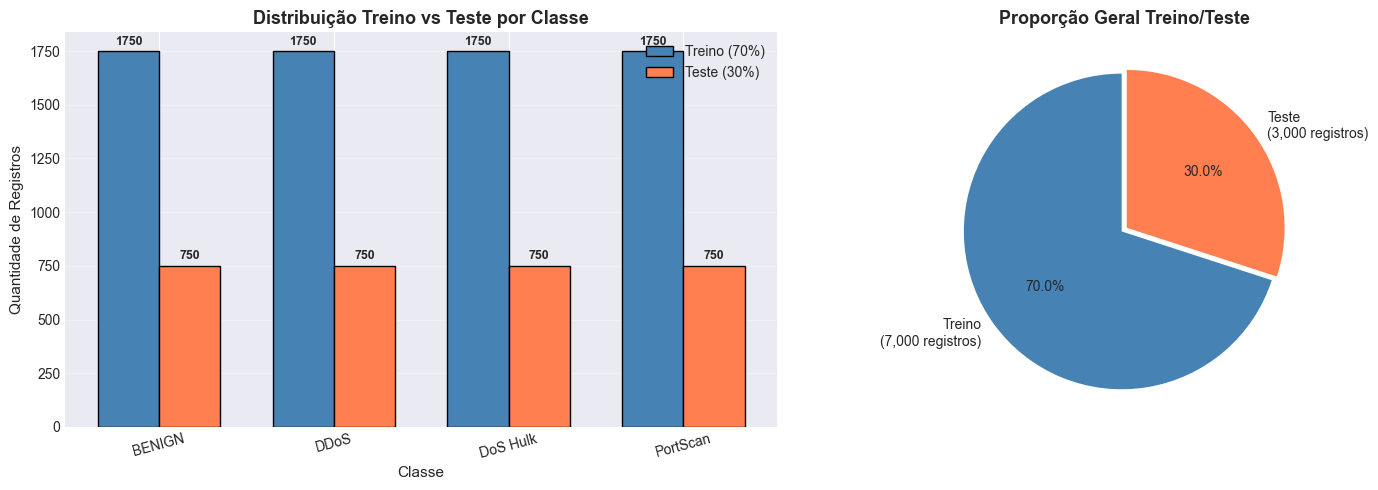

In [7]:
# criando visualização comparativa da divisão treino/teste
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cores = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
nomes_classes = list(codificador.classes_)

# gráfico de barras da distribuição do treino vs teste
treino_counts = [(y_train == c).sum() for c in range(len(nomes_classes))]
teste_counts = [(y_test == c).sum() for c in range(len(nomes_classes))]

x_pos = np.arange(len(nomes_classes))
largura = 0.35

axes[0].bar(x_pos - largura/2, treino_counts, largura, 
            label='Treino (70%)', color='steelblue', edgecolor='black')
axes[0].bar(x_pos + largura/2, teste_counts, largura, 
            label='Teste (30%)', color='coral', edgecolor='black')

axes[0].set_xlabel('Classe', fontsize=11)
axes[0].set_ylabel('Quantidade de Registros', fontsize=11)
axes[0].set_title('Distribuição Treino vs Teste por Classe', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(nomes_classes, rotation=15)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# adicionando valores nas barras
for i, (t, te) in enumerate(zip(treino_counts, teste_counts)):
    axes[0].text(i - largura/2, t + 30, str(t), ha='center', fontweight='bold', fontsize=9)
    axes[0].text(i + largura/2, te + 30, str(te), ha='center', fontweight='bold', fontsize=9)

# gráfico de pizza da distribuição do treino vs teste
axes[1].pie([len(y_train), len(y_test)], 
            labels=[f'Treino\n({len(y_train):,} registros)', f'Teste\n({len(y_test):,} registros)'],
            autopct='%1.1f%%',
            colors=['steelblue', 'coral'],
            startangle=90,
            explode=(0.02, 0.02))
axes[1].set_title('Proporção Geral Treino/Teste', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [8]:
# definindo a pasta para salvar os conjuntos divididos
pasta_treino_teste = '../dados/dados_processados/treino_teste/'

# criando a pasta se não existir
os.makedirs(pasta_treino_teste, exist_ok=True)

print(f"Salvando conjuntos em: {pasta_treino_teste}\n")

# definindo todos os arquivos a serem salvos
arquivos_a_salvar = {
    # conjuntos da versão Original
    'X_train_original.csv': X_train_orig,
    'X_test_original.csv': X_test_orig,
    
    # conjuntos da versão PCA
    'X_train_pca.csv': X_train_pca,
    'X_test_pca.csv': X_test_pca,
    
    # conjuntos da versão LDA
    'X_train_lda.csv': X_train_lda,
    'X_test_lda.csv': X_test_lda,
    
    # rótulos 
    'y_train.csv': y_train,
    'y_test.csv': y_test,
}

# salvando cada arquivo
for nome_arquivo, dados in arquivos_a_salvar.items():
    caminho_completo = os.path.join(pasta_treino_teste, nome_arquivo)
    
    if isinstance(dados, pd.Series):
        dados.to_csv(caminho_completo, index=False)
    else:
        dados.to_csv(caminho_completo, index=False)
    
    tamanho_kb = os.path.getsize(caminho_completo) / 1024
    print(f" {nome_arquivo:<28} ({dados.shape}) - {tamanho_kb:.1f} KB")

print(f"\nTotal de arquivos salvos: {len(arquivos_a_salvar)}")


Salvando conjuntos em: ../dados/dados_processados/treino_teste/

 X_train_original.csv         ((7000, 78)) - 9606.7 KB
 X_test_original.csv          ((3000, 78)) - 4117.6 KB
 X_train_pca.csv              ((7000, 15)) - 1984.2 KB
 X_test_pca.csv               ((3000, 15)) - 850.5 KB
 X_train_lda.csv              ((7000, 3)) - 395.5 KB
 X_test_lda.csv               ((3000, 3)) - 169.5 KB
 y_train.csv                  ((7000,)) - 20.5 KB
 y_test.csv                   ((3000,)) - 8.8 KB

Total de arquivos salvos: 8


In [9]:
# resumo 
print(" RESUMO FINAL")
print("=" * 65)
print(f"{'Versão':<12} {'Atributos':<12} {'Treino':<10} {'Teste':<10} {'Total':<10}")
print("=" * 65)
print(f"{'Original':<12} {X_train_orig.shape[1]:<12} {X_train_orig.shape[0]:<10,} {X_test_orig.shape[0]:<10,} {n_total:<10,}")
print(f"{'PCA':<12} {X_train_pca.shape[1]:<12} {X_train_pca.shape[0]:<10,} {X_test_pca.shape[0]:<10,} {n_total:<10,}")
print(f"{'LDA':<12} {X_train_lda.shape[1]:<12} {X_train_lda.shape[0]:<10,} {X_test_lda.shape[0]:<10,} {n_total:<10,}")
print("=" * 65)



 RESUMO FINAL
Versão       Atributos    Treino     Teste      Total     
Original     78           7,000      3,000      10,000    
PCA          15           7,000      3,000      10,000    
LDA          3            7,000      3,000      10,000    
